# Homework 4

## 1. Bid-ask imbalance

(a) Pick a large-tick futures contract (see HW3). Sample the midpoint, the micro-price, and the indicator S as above on a regular grid of sample times, say at 10-second intervals from 07:00 to 15:00 on a range of dates.

For a large-tick futures contract, we select the 10-Year Treasury Note (`ZNH4`). The bid-ask spread is typically tightly bound to the minimum tick size with deep order book queues, making it an excellent candidate for the imbalance signal.

We sample the order book on a regular 10-second grid between 07:00 and 15:00 using an as-of join (`aj`) in Q to fetch the most recent quotes. We compute the midpoint, micro-price, and the imbalance $S = (q_B - q_A)/(q_B + q_A)$.

In [ ]:
library(rkdb)

host <- "hfm.princeton.edu"
port <- 6007L

h <- open_connection(host, port)
cat("Connected to", host, "on port", port, "\n")

sym <- "ZNH4"
dates <- c("2024.02.05", "2024.02.06", "2024.02.07", "2024.02.08", "2024.02.09")
dt <- 10
nt <- (15 - 7) * 60 * 60 / dt

results <- list()

for (d in dates) {
  qT <- paste0('([] t: 0D07:00:00 + ', dt, ' * 1000000000 * til ', nt, ')')
  qQ <- paste0('select last bid, last ask, last bsiz, last asiz by t:time from quote where date=', d, ', sym=`', sym)
  qJoin <- paste0('aj[`t; ', qT, '; ', qQ, ']')
  
  qCalc <- paste0(
    'select t, bid, ask, bsiz, asiz, ',
    'midpoint: 0.5*(bid+ask), ',
    'microprice: ((bsiz*ask) + (asiz*bid)) % (bsiz+asiz), ',
    'S: (bsiz-asiz) % (bsiz+asiz) ',
    'from ', qJoin, ' where not null bid'
  )
  
  qFinal <- qCalc
  
  df <- execute(h, qFinal)
  
  if(nrow(df) > 0) {
    df$date <- as.Date(d, format="%Y.%m.%d")
    results[[d]] <- df
  }
}

df_imbalance <- do.call(rbind, results)

print(head(df_imbalance))

Connected to hfm.princeton.edu on port 6007 
                          t      bid      ask bsiz asiz midpoint microprice
2024.02.05.1 25200000000000 111.0938 111.1094 2200 1290 111.1016   111.1036
2024.02.05.2 25210000000000 111.0781 111.0938 2657  523 111.0859   111.0912
2024.02.05.3 25220000000000 111.0781 111.0938  667 2182 111.0859   111.0818
2024.02.05.4 25230000000000 111.0781 111.0938  397 2533 111.0859   111.0802
2024.02.05.5 25240000000000 111.0781 111.0938 1374 2335 111.0859   111.0839
2024.02.05.6 25250000000000 111.0781 111.0938 2306  373 111.0859   111.0916
                      S       date
2024.02.05.1  0.2607450 2024-02-05
2024.02.05.2  0.6710692 2024-02-05
2024.02.05.3 -0.5317655 2024-02-05
2024.02.05.4 -0.7290102 2024-02-05
2024.02.05.5 -0.2590995 2024-02-05
2024.02.05.6  0.7215379 2024-02-05


### 1(b) Direction of the next midpoint change

For each time t, we need to determine the direction of the next midpoint change. Because the price might not change for several intervals, multiple sample times may end up using the same future midpoint change. 

To solve this efficiently in Q, we build a second query that isolates only the moments where a price change actually occurs by filtering out zero values. We then use the next operator to grab the upcoming change. Finally, we combine our first query from part (a) with this new query using an as-of join.

In [ ]:
results_1b <- list()

for (d in dates) {
  qT <- paste0('([] t: 0D07:00:00 + ', dt, ' * 1000000000 * til ', nt, ')')
  qQ <- paste0('select last bid, last ask, last bsiz, last asiz by t:time from quote where date=', d, ', sym=`', sym)
  q1 <- paste0('aj[`t; ', qT, '; ', qQ, ']')
  q1 <- paste0(
    'select t, bid, ask, bsiz, asiz, ',
    'midpoint: 0.5*(bid+ask), ',
    'microprice: ((bsiz*ask) + (asiz*bid)) % (bsiz+asiz), ',
    'S: (bsiz-asiz) % (bsiz+asiz) ',
    'from ', q1, ' where not null bid'
  )
  q2 <- paste0('select pm: 0.5*(last bid + last ask) by t:time from quote where date=', d, ', sym=`', sym)
  q2 <- paste0('update dp: deltas pm from ', q2)
  q2 <- paste0('select from (', q2, ') where 0<>dp')
  q2 <- paste0('update nextt: next t, nextdp: next dp from ', q2)
  qFinal <- paste0('update direction: signum nextdp, time_to_change: nextt-t from aj[`t; ', q1, '; ', q2, ']')
  
  df <- execute(h, qFinal)
  
  if(nrow(df) > 0) {
    df$date <- as.Date(d, format="%Y.%m.%d")
    results_1b[[d]] <- df
  }
}

df_combined <- do.call(rbind, results_1b)

print(head(df_combined[, c("t", "midpoint", "S", "nextdp", "direction")]))

                          t midpoint          S     nextdp direction
2024.02.05.1 25200000000000 111.1016  0.2607450 -0.0156250        -1
2024.02.05.2 25210000000000 111.0859  0.6710692  0.0078125         1
2024.02.05.3 25220000000000 111.0859 -0.5317655 -0.0156250        -1
2024.02.05.4 25230000000000 111.0859 -0.7290102  0.0078125         1
2024.02.05.5 25240000000000 111.0859 -0.2590995  0.0078125         1
2024.02.05.6 25250000000000 111.0859  0.7215379 -0.0156250        -1


### 1(c) Grouping and Plotting Conditional Probability

For the final part of question 1, we need to group the values of the imbalance indicator S into 20 bins of length 0.1. Once binned, we will calculate the empirical probability that the next midpoint change is up, conditional on the imbalance being in each specific bin. 

We will create a binary indicator that equals 1 if the next move is up, and 0 if it is down. Taking the mean of this indicator within each bin gives us the exact conditional probability requested to recreate Figure 1.

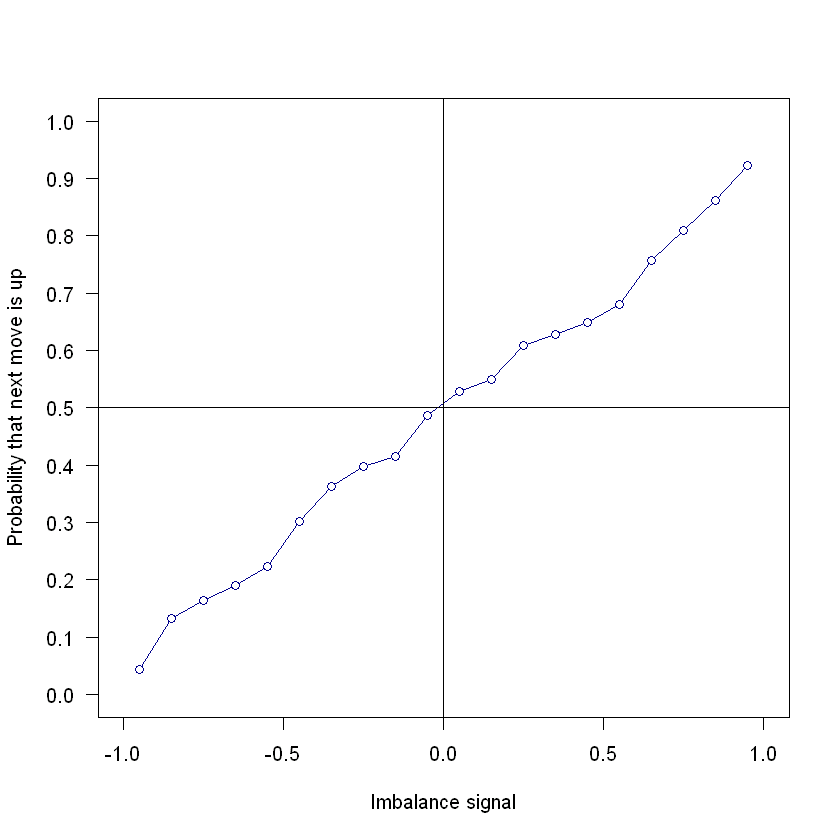

In [12]:
df_clean <- df_combined[!is.na(df_combined$S) & !is.na(df_combined$direction), ]

df_clean$is_up <- ifelse(df_clean$direction == 1, 1, 0)

breaks <- seq(-1, 1, by = 0.1)

df_clean$S_bin <- cut(df_clean$S, breaks = breaks, include.lowest = TRUE, labels = FALSE)

bin_midpoints <- breaks[-length(breaks)] + 0.05
df_clean$S_bin_mid <- bin_midpoints[df_clean$S_bin]

prob_up <- aggregate(is_up ~ S_bin_mid, data = df_clean, FUN = mean)

plot(prob_up$S_bin_mid, prob_up$is_up, type = "o", pch = 21, bg = "white", col = "darkblue",
     xlab = "Imbalance signal", ylab = "Probability that next move is up",
     ylim = c(0, 1), xlim = c(-1, 1), axes = FALSE)

axis(1, at = seq(-1, 1, by = 0.5))
axis(2, at = seq(0, 1, by = 0.1), las = 1)
box()

abline(h = 0.5, col = "black", lwd = 0.5)
abline(v = 0.0, col = "black", lwd = 0.5)

## 2. Pairs Trading

### (a) For your favorite pair of assets, extract quote midpoint prices at each of a regular set of time points. Start the calculation at the beginning of the day.

For our pairs trading algorithm, we will analyze the relationship between the 5-Year US Treasury Note (`ZFH4`) and the 10-Year US Treasury Note (`ZNH4`). These are highly correlated assets that typically move together, making them ideal candidates for a cointegration/pairs trading signal.

To allow our rolling averages and correlation matrices to calibrate properly before the main trading session starts at 07:00, we will begin our sampling at midnight (00:00:00) and run through 15:00:00. We use a 10-second sampling grid. In Q, we can perform two sequential as-of joins (`aj`) to align the midpoint prices of both assets perfectly onto the same time grid.

In [ ]:
sym1 <- "ZFH4"
sym2 <- "ZNH4"
dates <- c("2024.02.05", "2024.02.06", "2024.02.07", "2024.02.08", "2024.02.09")
dt <- 10
nt <- 15 * 60 * 60 / dt

results_2a <- list()

for (d in dates) {
  qT <- paste0('([] t: 0D00:00:00 + ', dt, ' * 1000000000 * til ', nt, ')')
  qQ1 <- paste0('select pm1: 0.5*(last bid + last ask) by t:time from quote where date=', d, ', sym=`', sym1)
  qQ2 <- paste0('select pm2: 0.5*(last bid + last ask) by t:time from quote where date=', d, ', sym=`', sym2)
  qJoin1 <- paste0('aj[`t; ', qT, '; ', qQ1, ']')
  qJoin2 <- paste0('aj[`t; ', qJoin1, '; ', qQ2, ']')
  qFinal <- paste0('select from (', qJoin2, ') where not null pm1, not null pm2')
  
  df <- execute(h, qFinal)
  
  if(nrow(df) > 0) {
    df$date <- as.Date(d, format="%Y.%m.%d")
    results_2a[[d]] <- df
  }
}

df_pairs <- do.call(rbind, results_2a)
print(head(df_pairs))

                       t      pm1      pm2       date
2024.02.05.1           0 107.6445 111.3672 2024-02-05
2024.02.05.2 10000000000 107.6445 111.3672 2024-02-05
2024.02.05.3 20000000000 107.6445 111.3672 2024-02-05
2024.02.05.4 30000000000 107.6445 111.3672 2024-02-05
2024.02.05.5 40000000000 107.6445 111.3672 2024-02-05
2024.02.05.6 50000000000 107.6445 111.3672 2024-02-05


### 2(b) Computing Rolling Averages, Standard Deviations, and Correlation

For this step, we need to compute the rolling metrics at each time point throughout the day. To be computationally efficient and avoid recalculating from scratch at every tick, we maintain a running sum of $x$, $y$, $x^2$, $y^2$, and $xy$ (where $x$ and $y$ are the midprices of our two assets). 

Using these cumulative sums, we can directly calculate the rolling means, variances, covariance, and the correlation matrix components at every time step $N$. We process this day by day so that the running sums reset at the beginning of each new trading day.

In [ ]:
results_2b <- list()

for (d in unique(df_pairs$date)) {
  df_day <- subset(df_pairs, date == d)
  N <- seq_len(nrow(df_day))
  
  sum_x  <- cumsum(df_day$pm1)
  sum_y  <- cumsum(df_day$pm2)
  sum_x2 <- cumsum(df_day$pm1^2)
  sum_y2 <- cumsum(df_day$pm2^2)
  sum_xy <- cumsum(df_day$pm1 * df_day$pm2)
  
  mean_x <- sum_x / N
  mean_y <- sum_y / N
  var_x <- (sum_x2 / N) - (mean_x^2)
  var_y <- (sum_y2 / N) - (mean_y^2)
  cov_xy <- (sum_xy / N) - (mean_x * mean_y)
  
  sd_x <- sqrt(pmax(var_x, 0))
  sd_y <- sqrt(pmax(var_y, 0))
  cor_xy <- cov_xy / (sd_x * sd_y)
  cor_xy[is.na(cor_xy)] <- 0
  
  df_day$mean_pm1 <- mean_x
  df_day$mean_pm2 <- mean_y
  df_day$sd_pm1 <- sd_x
  df_day$sd_pm2 <- sd_y
  df_day$cov <- cov_xy
  df_day$cor <- cor_xy
  
  results_2b[[as.character(d)]] <- df_day
}

df_pairs_stats <- do.call(rbind, results_2b)
print(head(df_pairs_stats[, c("t", "pm1", "pm2", "mean_pm1", "sd_pm1", "cor")]))

                             t      pm1      pm2 mean_pm1 sd_pm1 cor
19758.2024.02.05.1           0 107.6445 111.3672 107.6445      0   0
19758.2024.02.05.2 10000000000 107.6445 111.3672 107.6445      0   0
19758.2024.02.05.3 20000000000 107.6445 111.3672 107.6445      0   0
19758.2024.02.05.4 30000000000 107.6445 111.3672 107.6445      0   0
19758.2024.02.05.5 40000000000 107.6445 111.3672 107.6445      0   0
19758.2024.02.05.6 50000000000 107.6445 111.3672 107.6445      0   0


### 2(c) Compute the SVD, coordinate transform, and signals

For a 2x2 correlation matrix with 1s on the diagonal and rho off the diagonal, the SVD and PCA coordinate transform can be written explicitly. The eigenvectors are simply the sum and difference of the standardized variables, scaled by 1/sqrt(2). 

Applying the coordinate transform as described in the lecture allows us to use the correlation coefficient to predict the standardized price of one asset based on the other. 

The predicted standardized price for asset 1 is rho times the standardized price of asset 2. We then apply the reverse transformation (multiplying by standard deviation and adding the mean) to get the predicted actual prices, x_star and y_star. Finally, we calculate the signals sx and sy by taking the difference between the predicted prices and the actual prices.

In [ ]:
# Standardize prices
df_pairs_stats$xs <- (df_pairs_stats$pm1 - df_pairs_stats$mean_pm1) / df_pairs_stats$sd_pm1
df_pairs_stats$ys <- (df_pairs_stats$pm2 - df_pairs_stats$mean_pm2) / df_pairs_stats$sd_pm2
df_pairs_stats$xs[is.na(df_pairs_stats$xs)] <- 0
df_pairs_stats$ys[is.na(df_pairs_stats$ys)] <- 0

# Coordinate transform
df_pairs_stats$xs_star <- df_pairs_stats$cor * df_pairs_stats$ys
df_pairs_stats$ys_star <- df_pairs_stats$cor * df_pairs_stats$xs

# Transform back to price scale
df_pairs_stats$x_star <- df_pairs_stats$mean_pm1 + (df_pairs_stats$xs_star * df_pairs_stats$sd_pm1)
df_pairs_stats$y_star <- df_pairs_stats$mean_pm2 + (df_pairs_stats$ys_star * df_pairs_stats$sd_pm2)

# Trading signals
df_pairs_stats$sx <- df_pairs_stats$x_star - df_pairs_stats$pm1
df_pairs_stats$sy <- df_pairs_stats$y_star - df_pairs_stats$pm2
print(head(df_pairs_stats[, c("t", "pm1", "x_star", "sx", "pm2", "y_star", "sy")]))

                             t      pm1   x_star sx      pm2   y_star sy
19758.2024.02.05.1           0 107.6445 107.6445  0 111.3672 111.3672  0
19758.2024.02.05.2 10000000000 107.6445 107.6445  0 111.3672 111.3672  0
19758.2024.02.05.3 20000000000 107.6445 107.6445  0 111.3672 111.3672  0
19758.2024.02.05.4 30000000000 107.6445 107.6445  0 111.3672 111.3672  0
19758.2024.02.05.5 40000000000 107.6445 107.6445  0 111.3672 111.3672  0
19758.2024.02.05.6 50000000000 107.6445 107.6445  0 111.3672 111.3672  0


### 2(d) Regress forward price changes against the signal
For the final step, we evaluate the predictive p
ower of our generated signal. We will calculate the 1-minute forward price change for one of our assets and run a linear regression using the signal as the independent variable.

Since our grid is sampled at 10-second intervals, a 1-minute forward lag corresponds to looking exactly 6 rows ahead. We will isolate a single trading day to prevent the forward-looking calculation from bleeding into the next day's morning session. After running the regression, a positive and statistically significant coefficient on the signal indicates that the asset's price reliably moves toward the predicted theoretical price.


Call:
lm(formula = fwd_change_pm1 ~ sx, data = df_reg)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.162544 -0.006293  0.000369  0.003568  0.046100 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.0001930  0.0001327  -1.455    0.146    
sx           0.0372745  0.0078432   4.752 2.06e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.009321 on 5392 degrees of freedom
Multiple R-squared:  0.004171,	Adjusted R-squared:  0.003987 
F-statistic: 22.59 on 1 and 5392 DF,  p-value: 2.062e-06



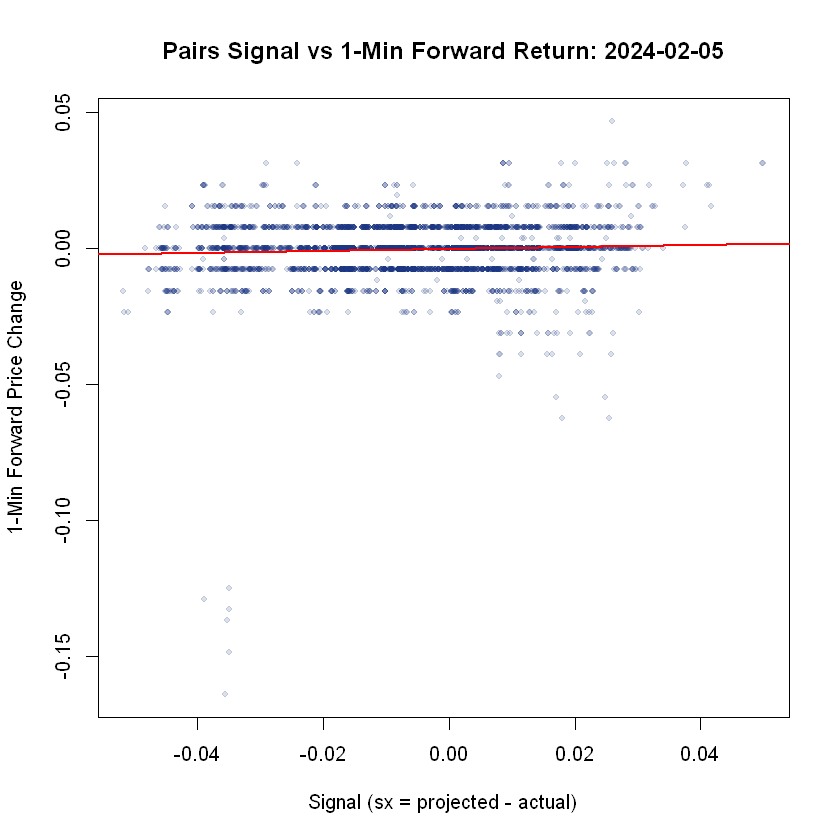

In [31]:
target_date <- unique(df_pairs_stats$date)[1]
df_day <- subset(df_pairs_stats, date == target_date)

lag_periods <- 60 / dt

future_pm1 <- c(df_day$pm1[(lag_periods + 1):nrow(df_day)], rep(NA, lag_periods))
df_day$fwd_change_pm1 <- future_pm1 - df_day$pm1

df_reg <- df_day[!is.na(df_day$fwd_change_pm1) & !is.na(df_day$sx), ]

model_x <- lm(fwd_change_pm1 ~ sx, data = df_reg)

print(summary(model_x))

plot(df_reg$sx, df_reg$fwd_change_pm1, 
     main = paste("Pairs Signal vs 1-Min Forward Return:", target_date),
     xlab = "Signal (sx = projected - actual)", 
     ylab = "1-Min Forward Price Change",
     pch = 20, col = rgb(0.1, 0.2, 0.5, 0.15))

abline(model_x, col = "red", lwd = 2)